In [1]:
import numpy as np
import sys,os
import scipy.special as sysp

import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol
import gc
from time import time
import json

from cobaya.samplers.mcmc import plot_progress

from getdist.mcsamples import MCSamplesFromCobaya,MCSamples
from getdist.mcsamples import loadMCSamples
%matplotlib inline  
import getdist.plots as gdplt

In [2]:
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12 # 14
mpl.rcParams['legend.labelspacing'] = 0.2

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3

#mpl.rcParams.keys()

***
# Quick Plots for Zel'dovich Smearing MCMC
***

In [3]:
Base_Dir = './'
Data_Dir = Base_Dir + 'data/'
Plots_Dir = Base_Dir + 'plots/'
Stats_Dir = Base_Dir + 'stats/'

Parallel = True
Modify_Data = True
Include_Sig2Obs = True
VaryMC = True

Accuracy = 'mid'

L_Max = 3

chain_file = 'stats/chains/'
chain_file += 'varymc/' if VaryMC else 'nomc/'
chain_file += 'zelsmear'
if Include_Sig2Obs:
    chain_file += '_inclSig2obs'
if not Modify_Data:
    chain_file += '_unmod'
if Accuracy != 'mid':
    chain_file += '_'+Accuracy+'acc'
if Parallel:
    chain_file += '_mpi'
if L_Max < 3:
    chain_file += '_LMax{0:d}'.format(L_Max)

Derived_List = ['f','peak','LP','ZC']
Derived_Latex = ['f','r_{\\rm peak}','r_{\\rm LP}','r_{\\rm ZC}']

# Use_Basis = np.array([0,1,3,5,7,8]) 
Use_Basis = np.arange(9)
N_Basis = len(Use_Basis)
dim = N_Basis + 7
if L_Max > 1:
    dim += 1
    if L_Max == 3:
        dim += 1
if Include_Sig2Obs:
    dim += 1
if not VaryMC:
    dim -= 1 # don't sample AMC
if Modify_Data & (L_Max > 1):
        dim -= 1 # don't sample qbar2 (for L_Max==2) or qbar4 (for L_Max==3)

Scales_File = Data_Dir + 'sdbmc_scales.txt'
Scales = np.loadtxt(Scales_File)

Ndata = Scales.size*L_Max
if Modify_Data & (L_Max > 1):
    Ndata -= 1
    if L_Max == 3:
        Ndata -= 1
if Include_Sig2Obs:
    Ndata += L_Max
dof = Ndata - dim
print('dof =',dof,'; dim =',dim)
print('chain file:',chain_file)

dof = 70 ; dim = 18
chain file: stats/chains/varymc/zelsmear_inclSig2obs_mpi


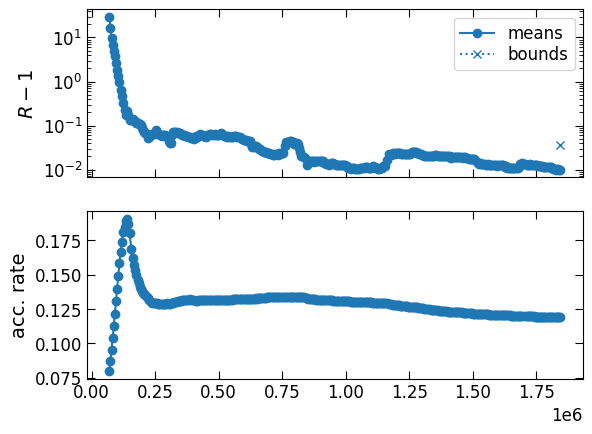

In [4]:
plot_progress(chain_file)
plt.show()

In [5]:
Show_Plots = False

gd_sample = loadMCSamples(os.path.abspath(chain_file),settings={'ignore_rows':0.3})
W_Names = ['w_{0:d}'.format(m) for m in Use_Basis] 
plot_param_list = ['beta','sigv']
plot_param_list.extend(W_Names)
plot_param_list += ['b','B1st','Bvst','sigma']
if VaryMC:
    plot_param_list += ['AMC']
if L_Max > 1:
    if (not Modify_Data) | (L_Max == 3):
        # note L_Max==3 not 2
        plot_param_list += ['qbar2']
    if (L_Max == 3) & (not Modify_Data):
        plot_param_list += ['qbar4']
if Include_Sig2Obs:
    plot_param_list += ['fv']
plot_param_list += Derived_List
plot_param_list += ['chi2']
print(plot_param_list)

Subplot_Size = 1.2

ibest = gd_sample.samples.T[-2].argmin()
mcmc_best = gd_sample.samples[ibest]
chi2_min = mcmc_best[-1]
i_last = 3 #if SDBMC else 1
mcmc_best = mcmc_best[:-i_last].copy()
mcmc_best[-1] = chi2_min
pval = sysp.gammainc(chi2_min/2,dof/2)
print(gd_sample.samples.shape[0],ibest,mcmc_best,chi2_min/dof,pval)

if Show_Plots:
    gdplot = gdplt.get_subplot_plotter(subplot_size=Subplot_Size)
    gdplot.settings.num_plot_contours = 3
    gdplot.settings.axes_fontsize = FS3
    gdplot.settings.axes_labelsize = FS2
    gdplot.settings.title_limit_fontsize = FS2
    gdplot.settings.title_limit = 1
    
    gdplot.triangle_plot([gd_sample], plot_param_list,
                         filled=[True],contour_colors=['indigo'],legend_loc='upper center',
                         markers=mcmc_best,
                         marker_args={'c': 'indigo','ls': ':','lw': 1.0,'alpha': 0.6})
    
    offset = 2
    par_show = np.arange(len(plot_param_list)) + offset
    par_show[-1] = -2
    
    for par_y in range(par_show.size):
        str_y = plot_param_list[par_y]
        for par_x in range(par_y):
            str_x = plot_param_list[par_x]
            ax = gdplot.subplots[par_y,par_x]
            ax.scatter([mcmc_best[par_x]],[mcmc_best[par_y]],
                       marker='*',s=50,c='white')
            
            
    show_chain = []
    for c in range(6):
        sample = np.loadtxt(os.path.abspath(chain_file)+'.'+str(c+1)+'.txt')
        sample = sample[int(0.3*sample.shape[0]):]
        sample = sample.T
        sample[-2] /= dof
        show_chain.append(sample[par_show])
    
    for p in range(par_show.size): 
        plt.figure(figsize=(2,2))
        plt.ylabel(plot_param_list[p])
        for c in range(6):
            plt.plot(show_chain[c][p],'-',lw=0.5)
        mark = mcmc_best[p]/dof if p == par_show.size-1 else mcmc_best[p]
        plt.axhline(mark,c='k',ls='--',lw=1)
        if p == par_show.size - 1:
            plt.axhline(1,c='k',ls=':',lw=1)
        plt.minorticks_on()
        plt.show()

['beta', 'sigv', 'w_0', 'w_1', 'w_2', 'w_3', 'w_4', 'w_5', 'w_6', 'w_7', 'w_8', 'b', 'B1st', 'Bvst', 'sigma', 'AMC', 'qbar2', 'fv', 'f', 'peak', 'LP', 'ZC', 'chi2']
1290808 946934 [ 2.8263496e-01  3.6735184e+00 -8.8662622e-04 -2.7756741e-02
 -1.6740352e-02  1.5518383e-02  1.1727283e-02  1.2297871e-02
 -5.7068987e-03 -7.4154435e-04  2.7989437e-02  2.4512330e+00
 -2.1785296e+00 -3.0305447e+00  5.7807179e+00  1.3213261e-02
  1.1347119e-01  3.0014292e-01  6.9280415e-01  9.9647285e+01
  9.2788538e+01  1.2028746e+02  9.6632464e+01] 1.3804637714285715 0.018867543507749013
